In [15]:
!pip -q install datasets pandas numpy matplotlib nltk transformers sentence-transformers bertopic umap-learn hdbscan scikit-learn

In [16]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download("vader_lexicon")
nltk.download("stopwords")

from datasets import load_dataset
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords

import torch
from transformers import pipeline
from sentence_transformers import SentenceTransformer

from bertopic import BERTopic
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use("default")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
ds = load_dataset("amazon_polarity", split="train[:5000]")

df = pd.DataFrame({
    "text": ds["content"],
    "label": ds["label"]
})

df.head()

README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

,text,label
0,This sound track was beautiful! It paints the ...,1
1,I'm reading a lot of reviews saying that this ...,1
2,This soundtrack is my favorite music of all ti...,1
3,I truly like this soundtrack and I enjoy video...,1
4,"If you've played the game, you know how divine...",1


In [18]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 20].reset_index(drop=True)

df.head()

,text,label,clean_text
0,This sound track was beautiful! It paints the ...,1,sound track beautiful paints senery mind well ...
1,I'm reading a lot of reviews saying that this ...,1,reading lot reviews saying best game soundtrac...
2,This soundtrack is my favorite music of all ti...,1,soundtrack favorite music time hands intense s...
3,I truly like this soundtrack and I enjoy video...,1,truly like soundtrack enjoy video game music p...
4,"If you've played the game, you know how divine...",1,youve played game know divine music every sing...


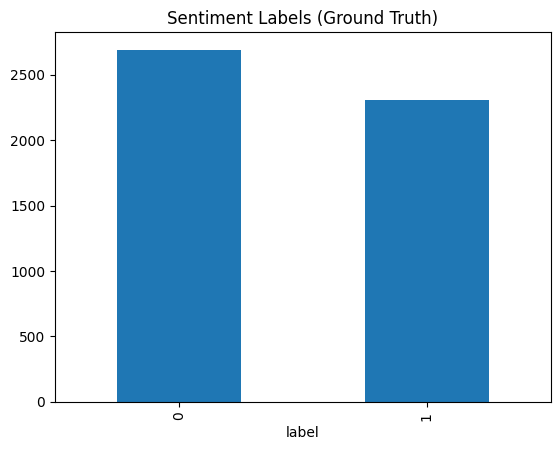

In [19]:
df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Labels (Ground Truth)")
plt.show()

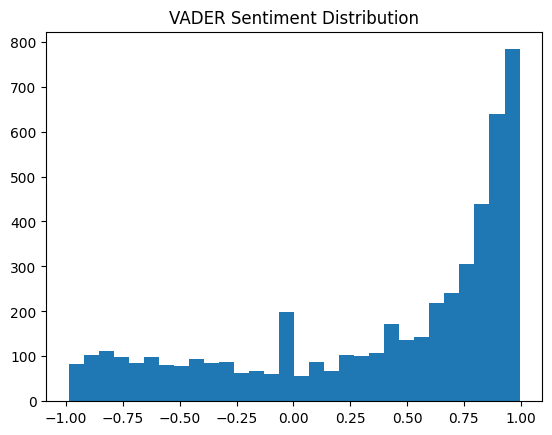

In [20]:
sia = SentimentIntensityAnalyzer()

df["vader_score"] = df["clean_text"].apply(lambda x: sia.polarity_scores(x)["compound"])

plt.hist(df["vader_score"], bins=30)
plt.title("VADER Sentiment Distribution")
plt.show()

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


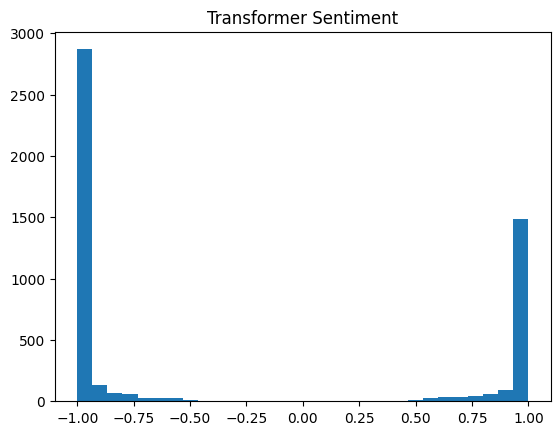

In [21]:
device = 0 if torch.cuda.is_available() else -1

sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

def transformer_sentiment(text):
    result = sentiment_model(text[:512])[0]
    return result["score"] if result["label"] == "POSITIVE" else -result["score"]

df["transformer_score"] = df["clean_text"].apply(transformer_sentiment)

plt.hist(df["transformer_score"], bins=30)
plt.title("Transformer Sentiment")
plt.show()

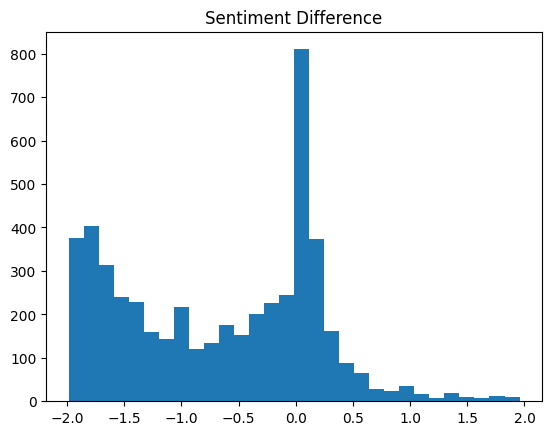

In [22]:
df["gap"] = df["transformer_score"] - df["vader_score"]

plt.hist(df["gap"], bins=30)
plt.title("Sentiment Difference")
plt.show()

In [23]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [24]:
topic_model = BERTopic()
topics, _ = topic_model.fit_transform(df["clean_text"].tolist())

df["topic"] = topics

topic_model.get_topic_info().head()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1371,-1_book_read_movie_one,"[book, read, movie, one, good, would, like, bo...",[personally enjoyed ever word particular work ...
1,0,641,0_album_music_songs_song,"[album, music, songs, song, band, sound, track...",[excellent album title track smoke rings excep...
2,1,178,1_bed_air_mattress_pump,"[bed, air, mattress, pump, sleep, airbed, comf...",[bought air mattress use new bed shipped back ...
3,2,126,2_adapter_apple_charger_power,"[adapter, apple, charger, power, charging, pow...",[power adapter charges powerbook excruciatingl...
4,3,102,3_series_books_book_romance,"[series, books, book, romance, read, character...",[okay first night world book read seemed prett...


In [25]:
topic_model.visualize_barchart(top_n_topics=10)

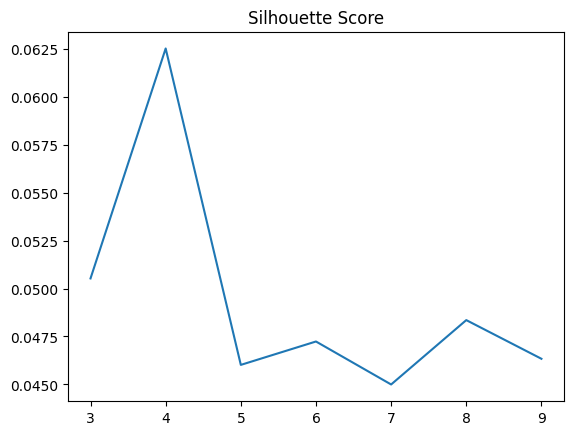

Best K: 4


In [26]:
scores = []
ks = range(3,10)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    scores.append(score)

plt.plot(ks, scores)
plt.title("Silhouette Score")
plt.show()

best_k = ks[np.argmax(scores)]
print("Best K:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42)
df["cluster"] = kmeans.fit_predict(embeddings)

In [27]:
df.groupby("cluster").agg({
    "vader_score":"mean",
    "transformer_score":"mean"
}).sort_values("transformer_score", ascending=False)

,vader_score,transformer_score
cluster,,
1,0.551465,-0.011000
3,0.400238,-0.084369
0,0.274544,-0.357506
2,0.338160,-0.540549


In [28]:
df.to_csv("amazon_nlp_analysis.csv", index=False)
print("Saved!")

Saved!
